In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [8]:
#load the data set
data = pd.read_csv("House_Rent_Dataset (1).csv")

In [11]:
data.sample(10)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
4738,2022-07-06,2,17000,855,4 out of 5,Carpet Area,"Godavari Homes, Quthbullapur",Hyderabad,Unfurnished,Bachelors,2,Contact Agent
1899,2022-06-30,1,6500,700,1 out of 4,Super Area,"Electronic City Phase 2, Electronic City",Bangalore,Unfurnished,Bachelors,1,Contact Owner
3448,2022-05-06,2,15000,805,Ground out of 2,Super Area,Kodambakkam,Chennai,Semi-Furnished,Bachelors/Family,2,Contact Owner
1497,2022-06-23,2,10500,800,3 out of 4,Super Area,Nagappa Reddy layout-Dooravani Nagar,Bangalore,Semi-Furnished,Bachelors/Family,2,Contact Owner
805,2022-04-29,2,50000,950,4 out of 8,Super Area,Ghatkopar East,Mumbai,Furnished,Bachelors/Family,2,Contact Owner
3642,2022-07-08,2,15000,700,Ground out of 2,Super Area,Alandur,Chennai,Semi-Furnished,Bachelors/Family,2,Contact Owner
3081,2022-06-22,3,12000,930,2 out of 8,Super Area,"Kelambakkam, Old Mahabalipuram Road",Chennai,Semi-Furnished,Family,2,Contact Owner
4214,2022-05-12,2,7500,950,1 out of 2,Super Area,Kothapet,Hyderabad,Unfurnished,Bachelors/Family,2,Contact Owner
1058,2022-07-05,1,35000,350,2 out of 3,Super Area,Dadar West,Mumbai,Unfurnished,Bachelors/Family,1,Contact Owner
2196,2022-06-11,1,7500,750,1 out of 1,Carpet Area,Bettadasanapura,Bangalore,Semi-Furnished,Bachelors/Family,1,Contact Owner


In [10]:
data.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [12]:
data.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [13]:
data.describe(include='object')

,Posted On,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Point of Contact
count,4746,4746,4746,4746,4746,4746,4746,4746
unique,81,480,3,2235,6,3,3,3
top,2022-07-06,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,Contact Owner
freq,311,379,2446,37,972,2251,3444,3216


In [14]:
data.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [19]:
#Drop the columns not required
data = data.drop(['Posted On', 'Area Locality', 'Floor'], axis=1)

In [20]:
data.columns

Index(['BHK', 'Rent', 'Size', 'Area Type', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Bathroom', 'Point of Contact'],
      dtype='object')

In [37]:
data.shape

(4746, 9)

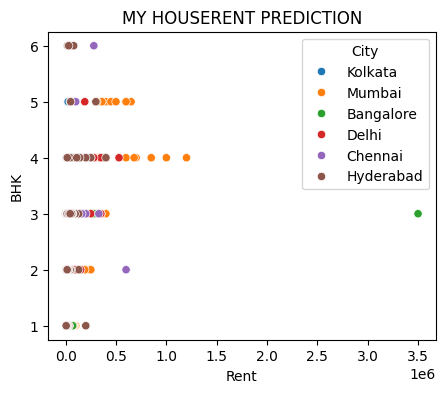

In [30]:
plt.figure(figsize= (5,4))
sns.scatterplot(x = "Rent", y = "BHK" , hue ="City" ,data = data)
plt.title("MY HOUSERENT PREDICTION")
plt.show()

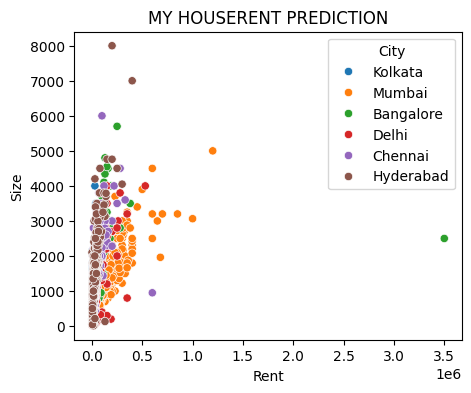

In [28]:
plt.figure(figsize= (5,4))
sns.scatterplot(x = "Rent", y = "Size" , hue ="City" ,data = data)
plt.title("MY HOUSERENT PREDICTION")
plt.show()

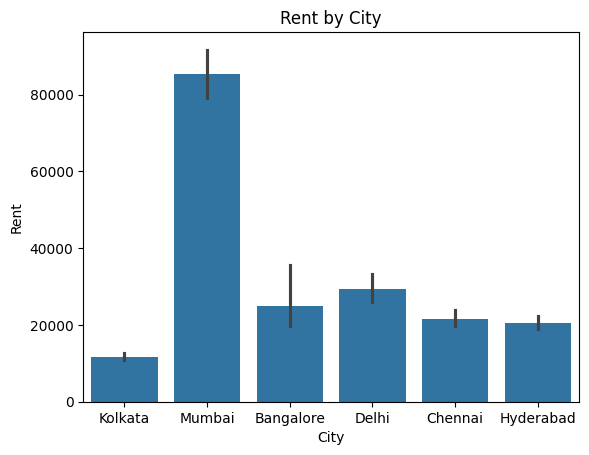

In [29]:
#Rent by city
sns.barplot(x = "City", y = "Rent", data = data)
plt.title("Rent by City")
plt.show()

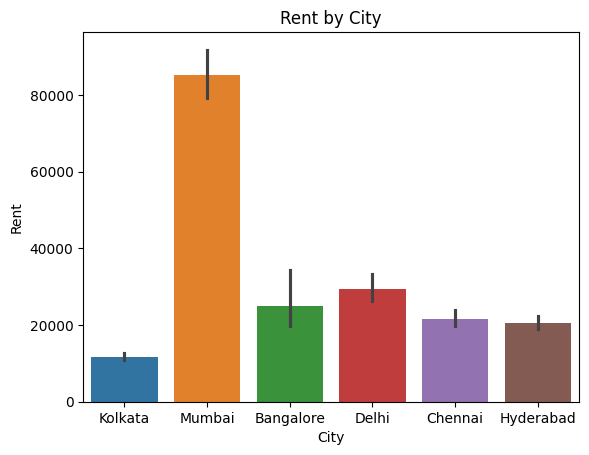

In [36]:
#Rent by city
sns.barplot(x = "City", y = "Rent",hue ="City",data = data)
plt.title("Rent by City")
plt.show()

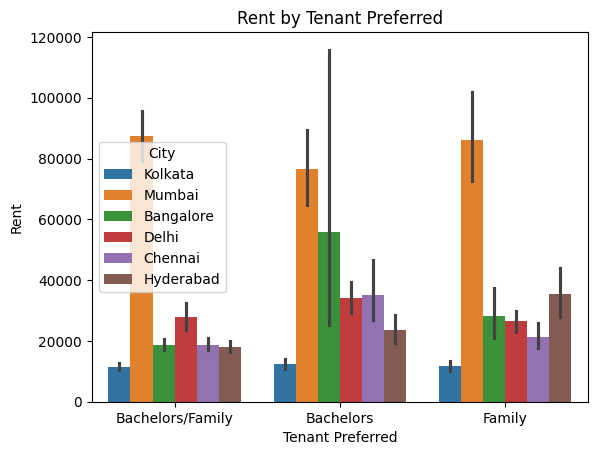

In [35]:
sns.barplot(x = "Tenant Preferred", y = "Rent",hue ="City" ,data = data)
plt.title("Rent by Tenant Preferred")
plt.show()


#Data Processing and Splitting

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [45]:
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols

Index(['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object')

In [48]:
for col in categorical_cols:
    print(f"{col} : {data[col].unique()}")

Area Type : ['Super Area' 'Carpet Area' 'Built Area']
City : ['Kolkata' 'Mumbai' 'Bangalore' 'Delhi' 'Chennai' 'Hyderabad']
Furnishing Status : ['Unfurnished' 'Semi-Furnished' 'Furnished']
Tenant Preferred : ['Bachelors/Family' 'Bachelors' 'Family']
Point of Contact : ['Contact Owner' 'Contact Agent' 'Contact Builder']


In [49]:
#n unique value for numbers
for col in categorical_cols:
    print(f"{col} : {data[col].nunique()}")

Area Type : 3
City : 6
Furnishing Status : 3
Tenant Preferred : 3
Point of Contact : 3


In [50]:
data.columns

Index(['BHK', 'Rent', 'Size', 'Area Type', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Bathroom', 'Point of Contact'],
      dtype='object')

In [53]:
x = data.drop(columns='Rent')
y = data['Rent']

In [54]:
print(x.head())
print(y.head())

   BHK  Size    Area Type     City Furnishing Status  Tenant Preferred  \
0    2  1100   Super Area  Kolkata       Unfurnished  Bachelors/Family   
1    2   800   Super Area  Kolkata    Semi-Furnished  Bachelors/Family   
2    2  1000   Super Area  Kolkata    Semi-Furnished  Bachelors/Family   
3    2   800   Super Area  Kolkata       Unfurnished  Bachelors/Family   
4    2   850  Carpet Area  Kolkata       Unfurnished         Bachelors   

   Bathroom Point of Contact  
0         2    Contact Owner  
1         1    Contact Owner  
2         1    Contact Owner  
3         1    Contact Owner  
4         1    Contact Owner  
0    10000
1    20000
2    17000
3    10000
4     7500
Name: Rent, dtype: int64


In [55]:
y.head()

0    10000
1    20000
2    17000
3    10000
4     7500
Name: Rent, dtype: int64

In [73]:
import category_encoders as ce
encoder = ce.LeaveOneOutEncoder (return_df =True)
x = encoder.fit_transform(x,y)

In [59]:
x.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [95]:
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
x = scalar.fit_transform(x)

In [77]:
X_df = pd.DataFrame(x)

In [78]:
X_df .head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [81]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [82]:
x_train.shape , y_train.shape

((3796, 8), (3796,))

In [ ]:
x_test.shape , y_test.shape 

((950, 8), (950,))

##Training models and evaluation of linear regression, random forest, decision tree

In [86]:
model_rfr = RandomForestRegressor()
model_dt = DecisionTreeRegressor()
model_ir = LinearRegression()
#model_xgb = XGBRRegressor(objective ='reg:squarederror')
models = [model_rfr, model_dt, model_ir]

In [92]:
#fitting data in all 3 models
for model in models:
        print(f"Training{model}")
        model.fit(x_train,y_train)

TrainingRandomForestRegressor()
TrainingDecisionTreeRegressor()
TrainingLinearRegression()


In [93]:
for model in models:
    print(f"score of {model}is : {model.score(x_test,y_test)}")

score of RandomForestRegressor()is : 0.9023310754052993
score of DecisionTreeRegressor()is : 0.9363720949086073
score of LinearRegression()is : 0.5153586519637426


In [104]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [4]:
import pandas as pd

#DEPLOYMENT


In [9]:
import pickle

encoder = pickle.load(open("encoder.pkl", "rb"))


In [13]:
new_data_encoder = encoder.transform(new_data)

In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore')
encoder.fit_transform(new_data)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (1, 8)>

In [23]:
import pickle

scaler = pickle.load(open("scaler.pkl", "rb"))


In [27]:
import pandas as pd
import pickle

# Load saved objects
model_rfr = pickle.load(open("house_rent_model.pkl", "rb"))
encoder = pickle.load(open("encoder.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# New input data
new_data = pd.DataFrame({
    "BHK": [3],
    "Size": [1200],
    "Bathroom": [2],
    "City": ["Hyderabad"],
    "Furnishing Status": ["Semi-Furnished"],
    "Area Type": ["Super built-up  Area"],
    "Tenant preferred": ["Family"],
    "Point of contact": ["Contact Owner"]
})

# Transform steps (same order as training)
new_data_encoder = encoder.transform(new_data)
new_data_scaled = scaler.transform(new_data_encoder)

# Prediction
rent = model_rfr.predict(new_data_scaled)

print("Predicted Rent:", rent[0])


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Point of contact
- Tenant preferred
Feature names seen at fit time, yet now missing:
- Point of Contact
- Tenant Preferred


In [110]:
import pickle

pickle.dump(model_rfr, open("house_rent_model.pkl", "wb"))
pickle.dump(encoder, open("encoder.pkl", "wb"))
pickle.dump(scalar, open("scaler.pkl", "wb"))
print("Models , Encoders , scaler saved successfully")

Models , Encoders , scaler saved successfully
